# **Loading Packages**
____

In [23]:
import numpy as np
import pandas as pd


from fredapi import Fred

import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import inv_boxcox
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# **Loading Data**
____

In [16]:
with open("API_key.txt", "r") as file:
    api_key = file.read().strip()

fred = Fred(api_key=api_key)
UK_GDP = fred.get_series('NGDPRSAXDCGBQ')
UK_GDP = pd.DataFrame(UK_GDP)
UK_GDP = UK_GDP.reset_index()

UK_GDP.columns = ['Date', 'GDP'] 

# **Modeling**
____

### **SARIMA w/ Original Data**

In [17]:
model_auto = auto_arima(y=UK_GDP['GDP'], start_P=0, 
                        start_q=0, m=4, information_criterion='aic')

In [18]:
print(model_auto)

 ARIMA(2,1,0)(0,0,1)[4] intercept


### **SARIMA w/ Box-Cox Transformation**

In [32]:
UK_GDP['Transformed'], opt_lambda = stats.boxcox(UK_GDP['GDP'])

model_auto_transformed = auto_arima(y=UK_GDP['Transformed'], start_P=0, 
                        start_q=0, m=4, information_criterion='aic')

In [33]:
print(model_auto_transformed)

 ARIMA(0,1,1)(0,0,1)[4] intercept


### **Comparing Results**

In [21]:
print(model_auto.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  283
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 4)   Log Likelihood               -2996.144
Date:                             Tue, 03 Feb 2026   AIC                           6002.288
Time:                                     14:35:34   BIC                           6020.497
Sample:                                          0   HQIC                          6009.590
                                             - 283                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2800.3190    626.400      4.470      0.000    1572.598    4028.040
ar.L1         -0.1721      

In [34]:
print(model_auto_transformed.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  283
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 4)   Log Likelihood                -549.641
Date:                           Tue, 03 Feb 2026   AIC                           1107.282
Time:                                   15:45:45   BIC                           1121.850
Sample:                                        0   HQIC                          1113.124
                                           - 283                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4472      0.124      3.604      0.000       0.204       0.690
ma.L1         -0.2575      0.017    -15.301

#### **Thoughts**
___
The Box-Cox model significantly outperforms the orignal dataset, thus we will use the given model parameters from the auto-arima function.

## **Fitting Final Model (GDP)**

In [29]:
GDP_Model = SARIMAX(endog=UK_GDP['Transformed'], order=(0,1,1), seasonal_order=(0,0,1,4))


GDP_Results = GDP_Model.fit()
Predicted = GDP_Results.forecast(steps=8)
forecast = inv_boxcox(Predicted, opt_lambda)


/var/folders/ts/x847bxb170n3msnnpmdpjll00000gn/T/ipykernel_17118/318146130.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=UK_GDP.index[-1], periods=9, freq='Q')[1:]


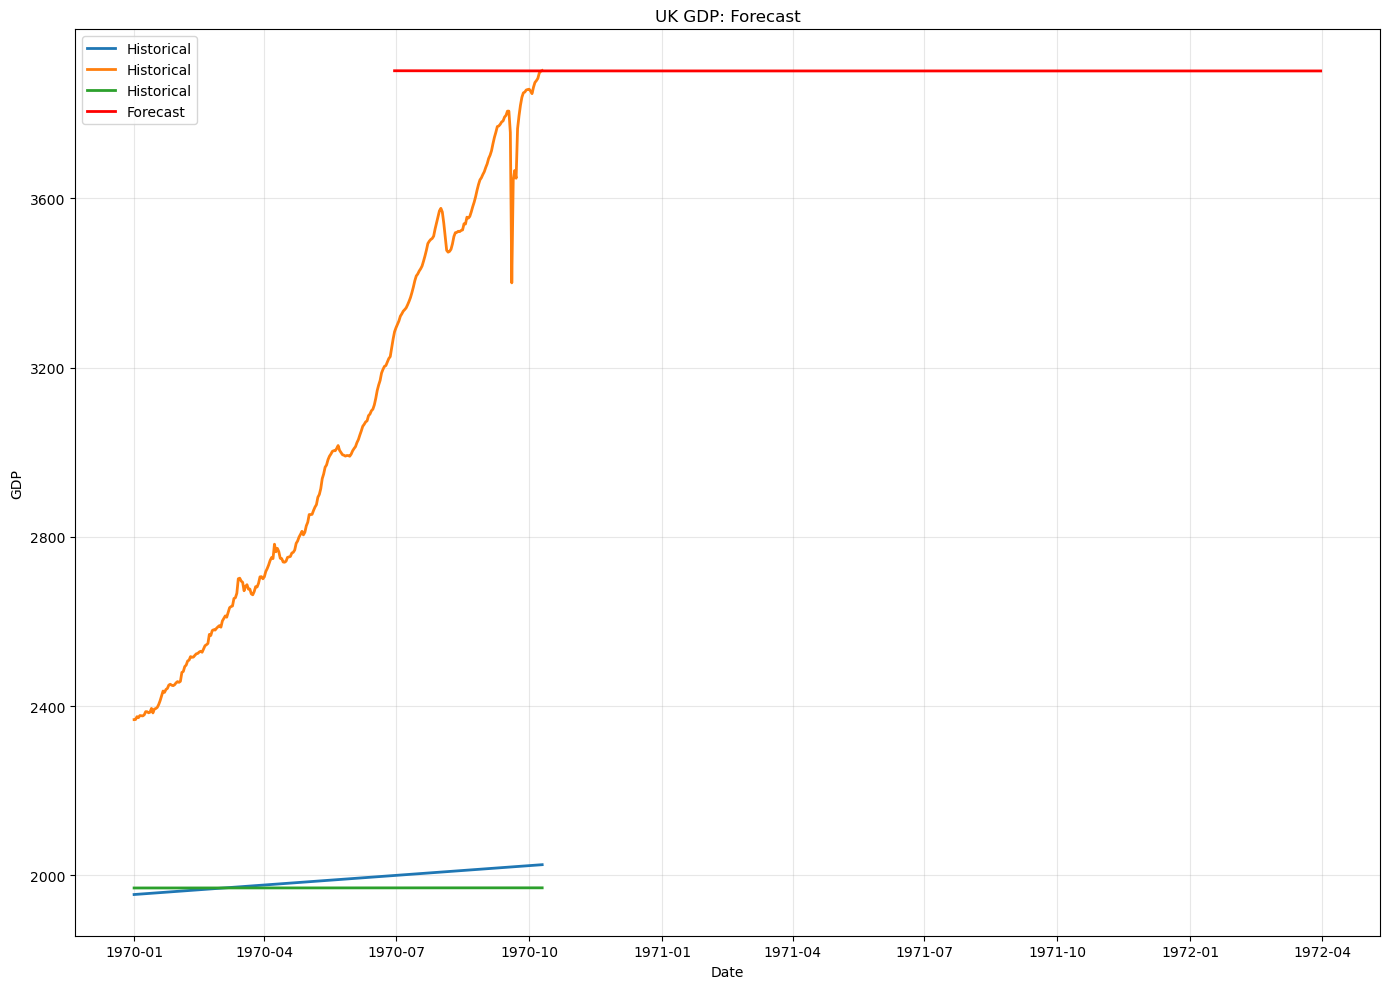

In [30]:
fig, ax = plt.subplots(figsize=(14, 10))

forecast_index = pd.date_range(start=UK_GDP.index[-1], periods=9, freq='Q')[1:]

ax.plot(UK_GDP.index, UK_GDP.values, label='Historical', linewidth=2)
ax.plot(forecast_index, forecast, label='Forecast', linewidth=2, color='red')
ax.set_title('UK GDP: Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('GDP')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()